<a href="https://colab.research.google.com/github/JoelLEMI/Analyses-of-bent-spindles-reveal-the-mechanics-of-anaphase-B-in-fission-yeast/blob/main/Codes/Cell%20Length%20%26%20width%20JL396_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''Take the contour of S.pombe segmented by Morphometrics (Matlab file)
find the middle line and measure the volume
assuming an axial symmetry and summing oblique cones all along + two spherical cap at the tip of the cell

test Colab modifications'''

'Take the contour of S.pombe segmented by Morphometrics (Matlab file)\nfind the middle line and measure the volume\nassuming an axial symmetry and summing oblique cones all along + two spherical cap at the tip of the cell\n\ntest Colab modifications'

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pylab as plt
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from scipy.io import loadmat
import os
import scipy.io
import urllib.request
import math

In [6]:
def MajorAxis(t,xcent,ycent,u,v):
    """Define the Major axis function from the eigen values y=a*x+b
    (xcent,ycent) center of the shape
    (u,v) eigenvalues
    """
    a=v/u
    b= ycent-xcent*a
    return a *  t + b


def calculate_distance(point1, point2,pxlSize):
    """Measure the distance between point1 and point2
    """
    x1, y1 = point1
    x2, y2 = point2
    distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2) * pxlSize
    return distance


def calculate_length(middle_positions,pxlSize):
    """Measure the distance along the Middle line of the cell
    """
    length = 0
    for i in range(1, len(middle_positions)):
        x1, y1 = middle_positions[i-1]
        x2, y2 = middle_positions[i]
        length += math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    return(length*pxlSize)


def MorphoNb(loc):
    """read Matlab file output from Morphometrics (loc) and return the Nb of cells analyzed (Nb),and
    the position of cells for wich no contour was found (ListNoCell)

    """
    # Load the MATLAB file
    mat = scipy.io.loadmat(loc)
    # Access the structure within the MATLAB file containing the number of images analyzed
    #nb =int(mat['i']) This line is to be used on Pascal post processing Matlab function
    nb = int(mat['Nframe'].item())

    # Access the structure within the MATLAB file
    mat_struct = mat['frame']

    # Record the images positions for wich morphometrics did not work in output
    output=[]
    for i in range(0, nb-1):
        output.append(int(mat_struct['num_objs'][0, i].item()))
    # Using enumerate to find positions of 0 (i.e. when Morphometrics did not find the cell)
    ListNoCell = [i for i, x in enumerate(output) if x == 0]

    # Number of cells really analyzed
    Nb=nb-len(ListNoCell)
    return (nb, Nb, ListNoCell)


def MorphoCont(loc, i):
    """read Matlab file output from Morphometrics (loc) and get the contour coordinates
    (x_contour,y_contour) for the selected cell "i"
    """
    # Load the MATLAB file
    mat = scipy.io.loadmat(loc)

    # Access the structure within the MATLAB file
    mat_struct = mat['frame']

    # Access specific fields within the structure
    field1 = mat_struct['object'][0,i] # Contains the parameters from Morphometrics about the contour

    x_contour=pd.DataFrame(field1['Xcont'][0,0])# Contains the array Xcont for cell i
    y_contour=pd.DataFrame(field1['Ycont'][0,0])# Contains the array Ycont for cell i
    #x_centerline=pd.DataFrame(field1['centerline2'][0,0][:,0]) # Contains the centerline from P
    #y_centerline=pd.DataFrame(field1['centerline2'][0,0][:,1]) # Contains the centerline from P
    #cell_Length_P=round(float(field1['cell_length'][0,0]),2)
    return (x_contour,y_contour)

def Cell_Axes(contour_coords):
    """take the contour of the cell (contour_coords) and give the axss from the eigenvalue decomposition
    """
    # Calculate the covariance matrix
    covariance_matrix = np.cov(contour_coords, rowvar=False)

    # Perform eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    # Find the major and minor axes
    major_axis_index = np.argmax(eigenvalues)
    minor_axis_index = np.argmin(eigenvalues)

    major_axis = eigenvectors[:, major_axis_index]
    minor_axis = eigenvectors[:, minor_axis_index]

    return (eigenvalues, eigenvectors,major_axis,minor_axis)


def Cell_Length(x_contour,y_contour,eigenvalues, eigenvectors,shape_polygon):
    """take the contour of the cell (contour_coords), the eigen values/vector and finds
    the extremities of the axis crossing the cell contour (Limit_point_1,Limit_point_2)
    """

    # Calculate the center point of the shape
    x_center = x_contour.squeeze().mean() #np.mean(x_contour)
    y_center = y_contour.squeeze().mean() #np.mean(y_contour)


    # Iterate through the major axis in upper direction
    for t in np.arange(0,100,0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_major_point = x_center + t * major_axis[0]
        y_major_point = y_center + t * major_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_major_point, y_major_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_1 = (x_major_point,y_major_point)

    # Iterate through the major axis in lower direction
    for t in np.arange(0,-100,-0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_major_point = x_center + t * major_axis[0]
        y_major_point = y_center + t * major_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_major_point, y_major_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_2 = (x_major_point,y_major_point)

    return (Limit_point_1,Limit_point_2)


def Cell_Width(x_contour,y_contour,eigenvalues, eigenvectors,shape_polygon):
    """take the contour of the cell (contour_coords), the eigen values/vector and finds
    the extremities of the axis crossing the cell contour (Limit_point_1,Limit_point_2)
    """

    # Calculate the center point of the shape
    x_center = x_contour.squeeze().mean() #np.mean(x_contour)
    y_center = y_contour.squeeze().mean() #np.mean(y_contour)


    # Iterate through the major axis in upper direction
    for t in np.arange(0,100,0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_minor_point = x_center + t * minor_axis[0]
        y_minor_point = y_center + t * minor_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_minor_point, y_minor_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_1 = (x_minor_point,y_minor_point)

    # Iterate through the major axis in lower direction
    for t in np.arange(0,-100,-0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_minor_point = x_center + t * minor_axis[0]
        y_minor_point = y_center + t * minor_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_minor_point, y_minor_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_2 = (x_minor_point,y_minor_point)

    return (Limit_point_1,Limit_point_2)

def Middle(x,y,eigenvalues, eigenvectors,shape_polygon):
    """takes position along the major axis (x,y), the eigen values/vector and finds
    the extremities of the axis crossing the cell contour (Limit_point_1,Limit_point_2)
    and the position of the middle of the cell (x_middle, y_middle)
    """


    # Iterate through the major axis in upper direction
    for t in np.arange(0,100,0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_minor_point = x + t * minor_axis[0]
        y_minor_point = y + t * minor_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_minor_point, y_minor_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_1 = (x_minor_point,y_minor_point)

    # Iterate through the major axis in lower direction
    for t in np.arange(0,-100,-0.1):  # Adjust the range of t and step (0.1µm as of now) as needed
        # Calculate the point on the major axis
        x_minor_point = x + t * minor_axis[0]
        y_minor_point = y + t * minor_axis[1]

        # Create a Point object for the current major axis point
        point = Point(x_minor_point, y_minor_point)

        # Check if the point lies within the shape
        if shape_polygon.contains(point):
            #print("Intersection point:", point , "iteration:" ,t)
            # Store the last point
            Limit_point_2 = (x_minor_point,y_minor_point)

    x_middle = (Limit_point_1[0]+Limit_point_2[0])/2
    y_middle = (Limit_point_1[1]+Limit_point_2[1])/2

    return (Limit_point_1,Limit_point_2,(x_middle,y_middle))


In [13]:
## Where data will be saved
locout=''

## Info about the data
Date = '2025-05-22' # Date of the experiment
Strain = 'JL396' # Strain name
Rep = '1' # Replicate number
Pxl = 0.16 # Pixel size

## Where Data are (raw GitHub URL)
loc_url = 'https://github.com/JoelLEMI/Colloid-osmotic-pressure-governs-nuclear-size-and-nucleoplasm-properties/raw/refs/heads/main/Data/JL396EMM_1/Data/PhaseJL396_05-Jun-2025_CONTOURS_pill_MESH.mat'

## Download the file locally so scipy can read it
## NOTE: These 3 lines are only needed if your data is hosted online (e.g. on GitHub).
## If you are working with a file that is already on your computer/Colab environment,
## you do NOT need this download step — simply set 'loc' directly to the local file path, e.g.:
##   loc = '/content/PhaseJL396_05-Jun-2025_CONTOURS_pill_MESH.mat'
## and skip the block below.
local_filename = os.path.basename(loc_url)
urllib.request.urlretrieve(loc_url, local_filename)
loc = local_filename  # now 'loc' points to a local file, not a URL

List2Nuclei = [32] # If a cell undergoes division it is manually removed here

## Extract information from Morphometrics segmentation on Phase contrast images
# nb = number of cell imaged,
# Nb = Number of cell successfully segmented,
# ListNoCell = Positions for which Morphometrics did not find the cell
nb,Nb,ListNoCell = MorphoNb(loc)


## Combine excluded cells for every reasons
Excluded = ListNoCell + List2Nuclei

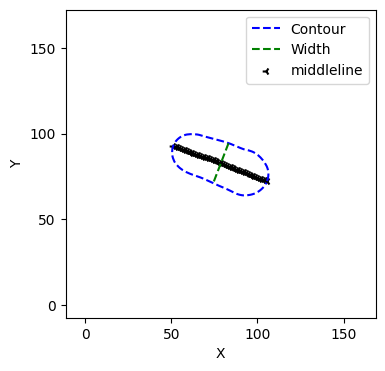

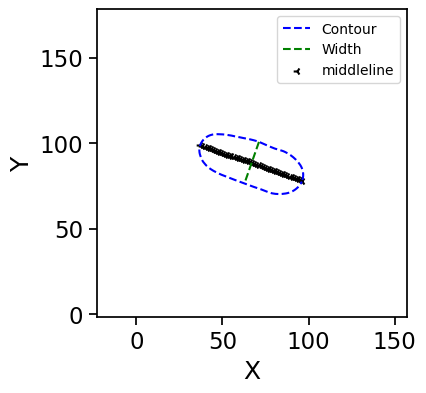

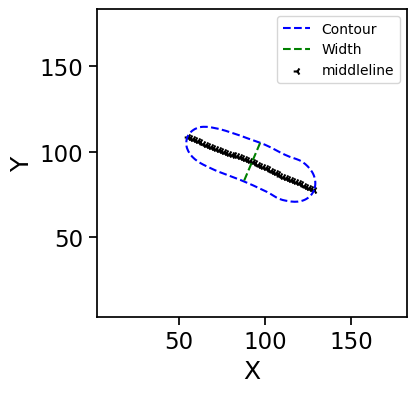

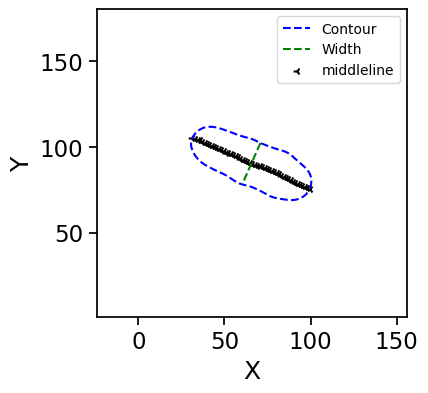

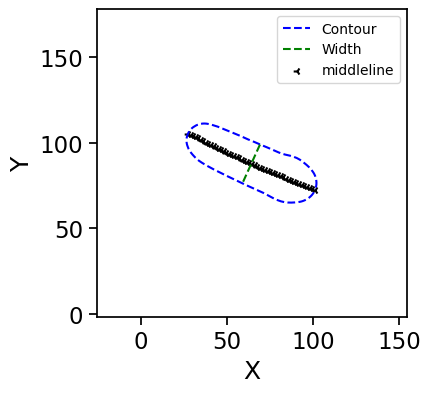

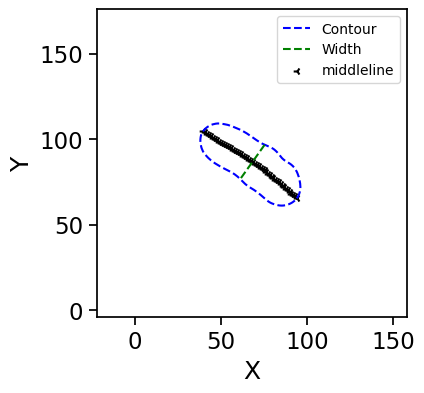

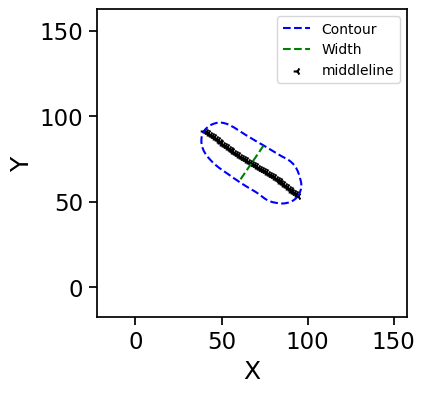

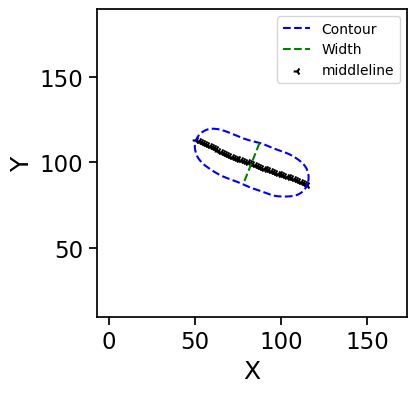

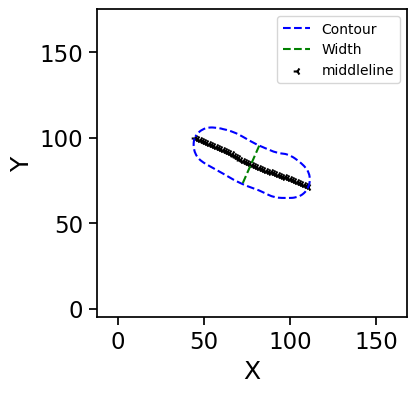

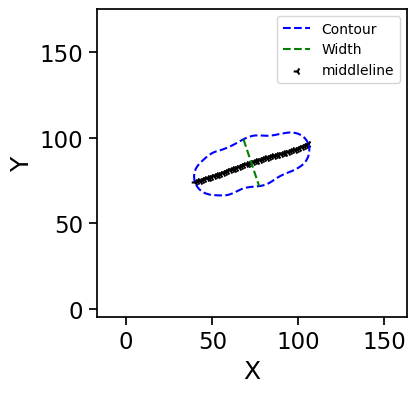

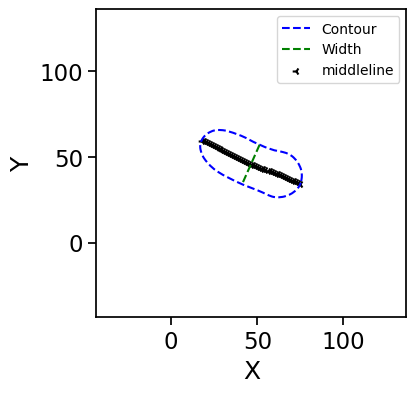

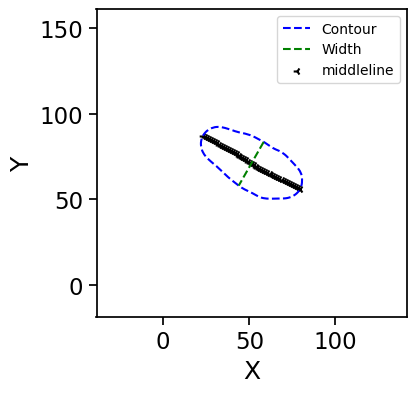

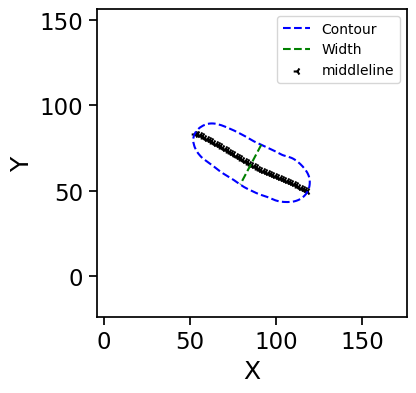

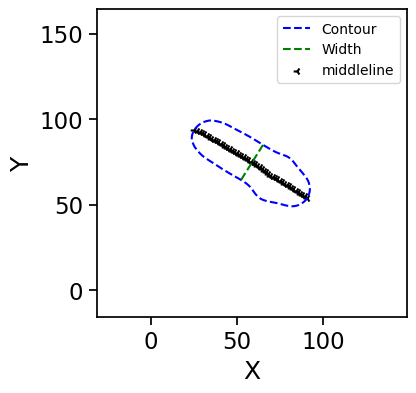

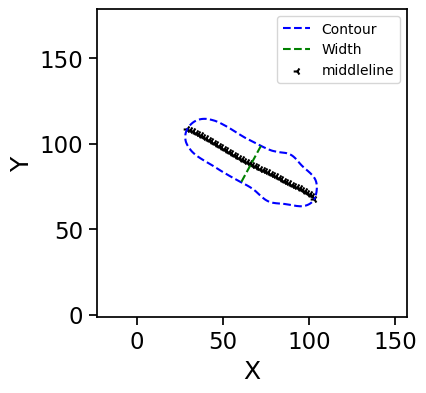

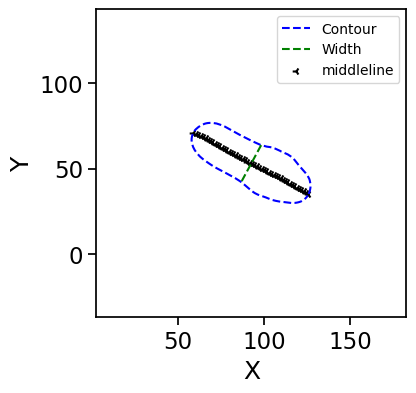

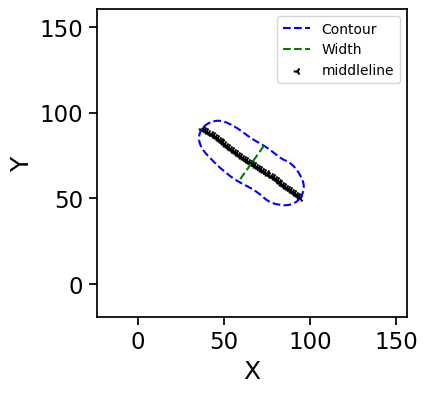

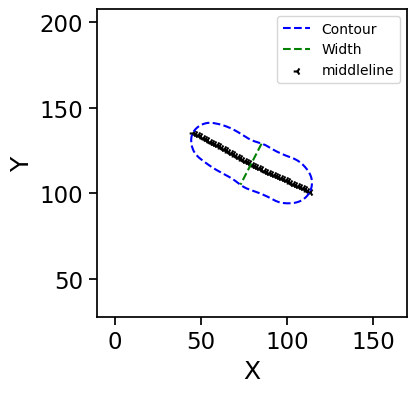

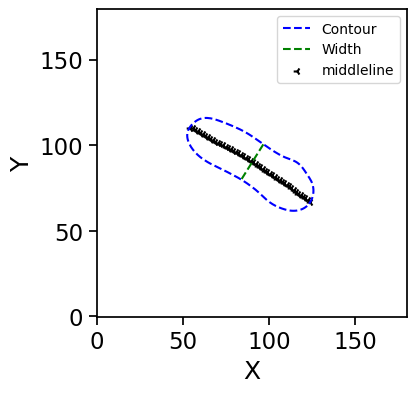

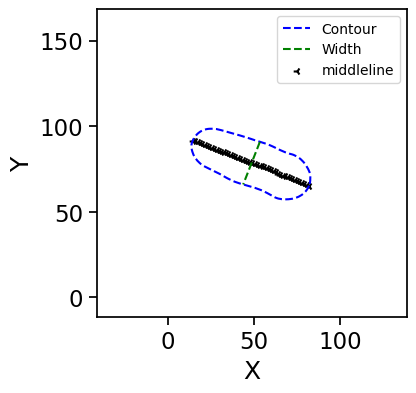

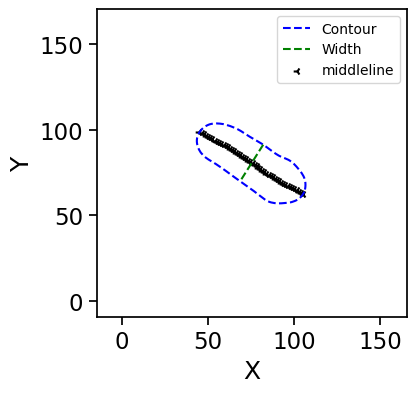

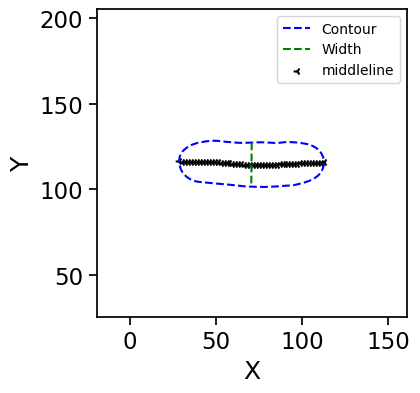

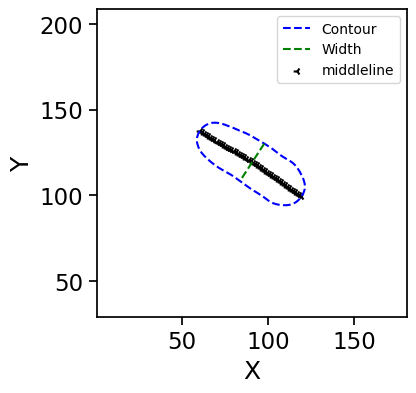

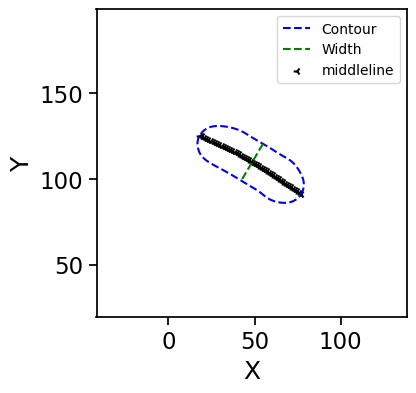

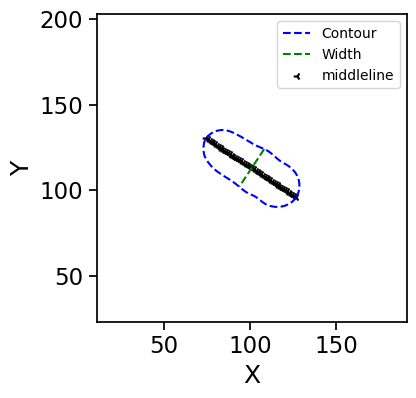

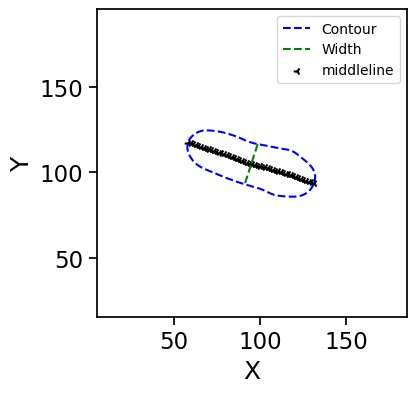

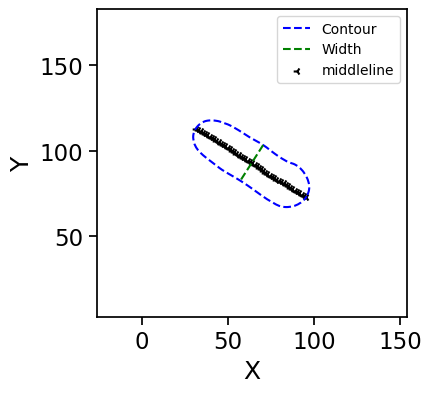

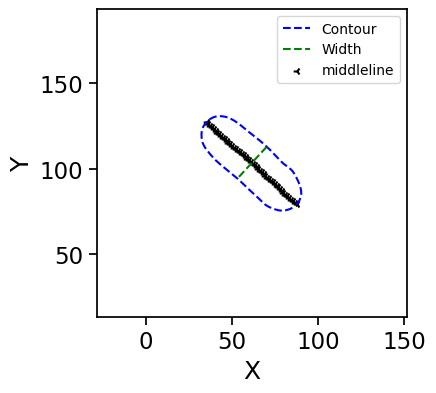

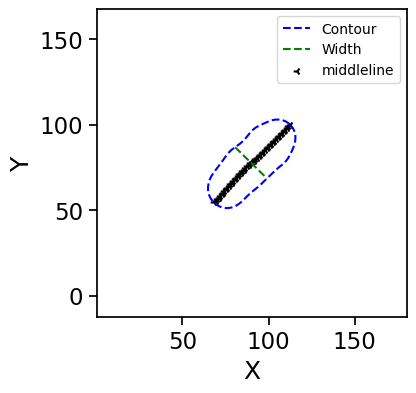

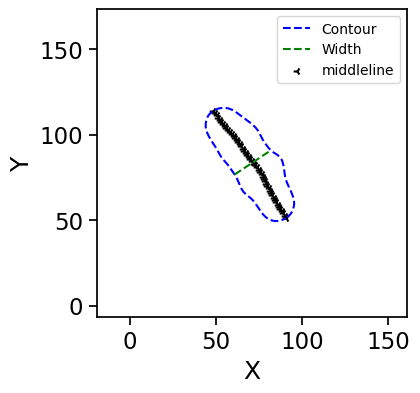

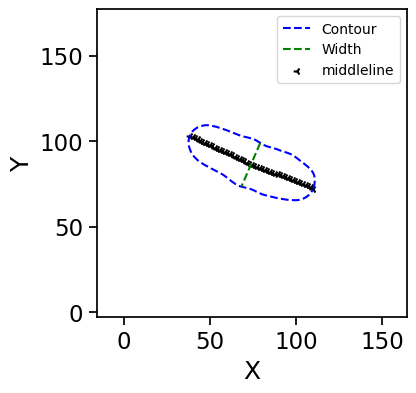

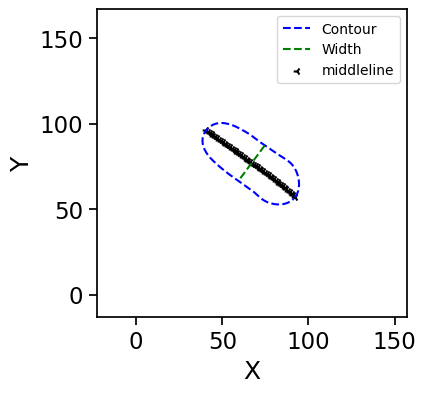

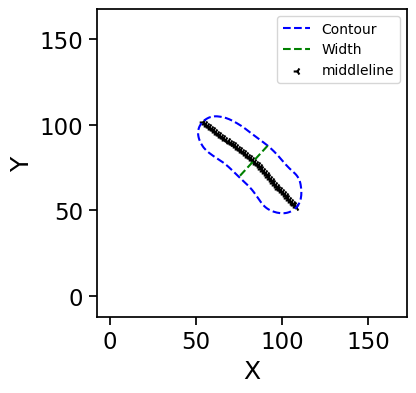

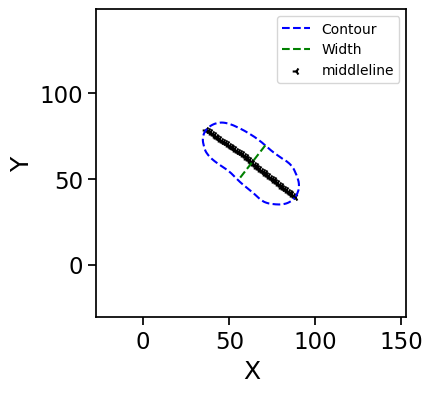

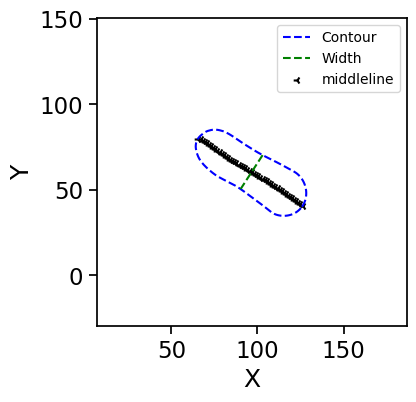

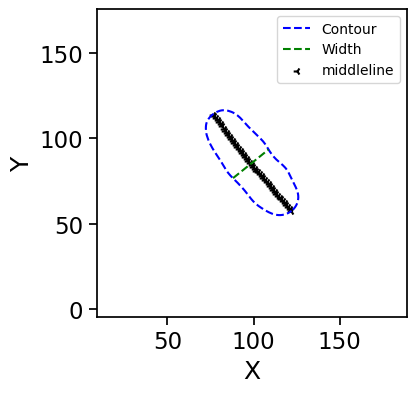

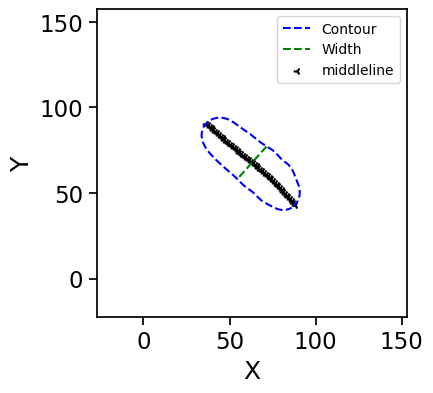

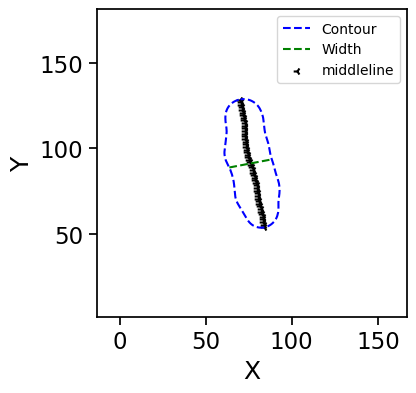

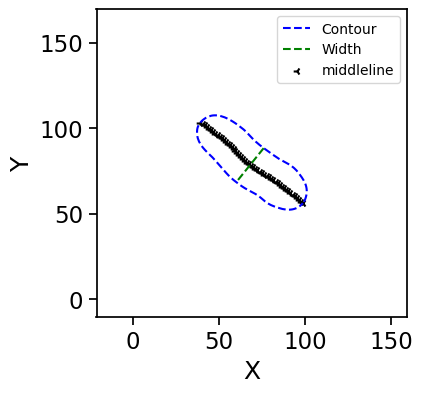

In [14]:
# Create DataFrame to save Data on strain name, date, Cell width, Cell length
df=pd.DataFrame()
Length=[]
Width=[]
Volume=[]
Position=[] # name of the field of view
# (x,y) are the coordinates of the center of the cell
Xc=[]
Yc=[]
# (x,y) are the coordinates of the tips (tip1 tip2) of the cell
Xt1=[]
Yt1=[]
Xt2=[]
Yt2=[]

a4_dims = (4,4)

for i in range(0,nb):
    if i in Excluded:
        # Save Positions
        Position.append(i+1)
        # add NaN for this position in the Table
        Length.append('NaN')
        Width.append('NaN')
        Volume.append('NaN')
        Xc.append('NaN')
        Yc.append('NaN')
        Xt1.append('NaN')
        Yt1.append('NaN')
        Xt2.append('NaN')
        Yt2.append('NaN')
        continue

    fig, ax = plt.subplots(figsize=a4_dims)   # new figure for each cell
    sns.set_context("notebook", font_scale=1.5)

    x_contour,y_contour=MorphoCont(loc, i)

    # Create a 2D array of the contour coordinates
    contour_coords = np.column_stack((x_contour, y_contour))

    # Create a Polygon object from the shape's perimeter coordinates
    shape_polygon = Polygon(zip(x_contour.squeeze(), y_contour.squeeze()))

    # Plot contour
    plt.plot(x_contour,y_contour,'b--',ms=0.5,label='Contour')

    # Find the major and minor axes
    eigenvalues, eigenvectors,major_axis,minor_axis = Cell_Axes(contour_coords)

    # Find cell lentgh
    Limit_point_1,Limit_point_2 = Cell_Length(x_contour,y_contour,eigenvalues, eigenvectors,shape_polygon)

    # Find cell Width
    Limit_point_a,Limit_point_b = Cell_Width(x_contour,y_contour,eigenvalues, eigenvectors,shape_polygon)

    # Plot Major & Minor axis
    t = np.linspace(Limit_point_a[0], Limit_point_b[0], 100)
    plt.plot(t, MajorAxis(t,x_contour.squeeze().mean(),y_contour.squeeze().mean(),minor_axis[0],minor_axis[1]), 'g--', label='Width')    #a=v/u
    #t = np.linspace(Limit_point_1[0], Limit_point_2[0], 100)
    #plt.plot(t, MajorAxis(t,x_contour.squeeze().mean(),y_contour.squeeze().mean(),major_axis[0],major_axis[1]), 'r--', label='Major Axis')    #a=v/u


    # Define the 50 points along the major axis to slice the cell
    num_points = 50
    x_points_along_major_axis = np.linspace(Limit_point_1[0],Limit_point_2[0], num_points)
    # Computing the corresponding y coordinates along the major axis
    y_points_along_major_axis= MajorAxis(x_points_along_major_axis,x_contour.squeeze().mean(),y_contour.squeeze().mean(),major_axis[0],major_axis[1])
    # Apply the function using a list comprehension
    result = [Middle(x,y,eigenvalues, eigenvectors,shape_polygon) for x, y in zip(x_points_along_major_axis, y_points_along_major_axis)]
    middle_positions = [tuple_[2] for tuple_ in result]

    # Extract x and y middle coordinates
    x_coords = [point[0] for point in middle_positions]
    y_coords = [point[1] for point in middle_positions]

    # Plot Middleline
    plt.scatter(x_coords, y_coords, s=30, marker='3',color='k',label='middleline')

    ## Measure volume
     # Extract (x,y) left & right shape coordinates
    left_positions = [tuple_[0] for tuple_ in result]
    right_positions = [tuple_[1] for tuple_ in result]
    # Extract x and y left & right side of the shape coordinates
    x_left_positions = [point[0] for point in left_positions]
    y_left_positions = [point[1] for point in left_positions]

    x_right_positions = [point[0] for point in right_positions]
    y_right_positions = [point[1] for point in right_positions]

    # h = ortogonal distance between two section (they are all the same-I just need to calculate once)
    h=calculate_distance((x_points_along_major_axis[0], y_points_along_major_axis[0]),
                                    (x_points_along_major_axis[1], y_points_along_major_axis[1]),Pxl)

    # R = Radius of the sections between the left edge and the middle
    R = [calculate_distance((x_left_positions[i], y_left_positions[i]),
                                    (x_coords[i], y_coords[i]),Pxl)
                 for i in range(len(x_left_positions))]

    # Calculate the hight of the caps
    hf=calculate_distance((x_points_along_major_axis[0], y_points_along_major_axis[0]),
                                    (x_points_along_major_axis[2], y_points_along_major_axis[2]),Pxl)
    # C = Volume of the two caps of the cell
    C1= np.pi*hf*(3*R[1]**2+hf**2)/6
    C2= np.pi*hf*(3*R[len(R)-2]**2+hf**2)/6
    C=C1+C2

    # Calculate the volume as an addition of oblique cones not taking the cap j=1 and j=len(R)-2
    V=[]
    for j in range(1,len(R)-2):
        v = np.pi*h/3 * (R[j]**2 + R[j+1]**2 + R[j]*R[j+1])
        V.append(v)

    # Total Volume
    Total_Volume=round(sum(V)+C1+C2,2)

    # Save volume
    Volume.append(Total_Volume)

    # Save Width along the cell length
    width = round(calculate_distance(Limit_point_a, Limit_point_b, Pxl),2)
    Width.append(width)

    # Measure 1 save Length of teh cell
    Length.append(round(calculate_length(middle_positions,Pxl),2))

    # Save Positions
    Position.append(i+1)

    # Save middle of the cell coordinates
    Xc.append( round((Limit_point_a[0]+Limit_point_b[0])/2))
    Yc.append( round((Limit_point_a[1]+Limit_point_b[1])/2))

    # Save the cell's tips positions
    Xt1.append(Limit_point_1[0])
    Yt1.append(Limit_point_1[1])
    Xt2.append(Limit_point_2[0])
    Yt2.append(Limit_point_2[1])

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend(fontsize='10',bbox_to_anchor=(1, 1))
    lx=x_contour.squeeze().mean()
    ly=y_contour.squeeze().mean()
    plt.xlim([lx-90,lx+90])
    plt.ylim([ly-90,ly+90])

    # Save an image of the cell and axis in Folder Figures
    # (Uncomment the two lines below if you want to save the images instead of just displaying them.
    # If running locally, make sure the Figures folder already exists first.)
    #plt.savefig(locout+"Figures/"+str(Strain)+"-"+Rep+"/Cell_"+str(Strain)+"_"+str(i)+".pdf",bbox_inches='tight')
    #plt.close()

    # Show an image of the cell and axis
    plt.show()


## Calling DataFrame after zipping both lists, with columns specified
df = pd.DataFrame(list(zip(Position,Length,Width,Xc,Yc,Xt1,Yt1,Xt2,Yt2,Volume)), columns =['Position','Length','Width','Xc','Yc','Xt1','Yt1','Xt2','Yt2','Volume'])
df['Strain'] = Strain
df['date'] = Date

## Save data as a CSV Table if you are running this code locally, uncomment the line below #df.to_csv
## The output should look like this file:
## https://github.com/JoelLEMI/Colloid-osmotic-pressure-governs-nuclear-size-and-nucleoplasm-properties/raw/refs/heads/main/Data/JL396EMM_1/Data/JL396-1.csv

#df.to_csv(locout+"Data/"+str(Strain)+"-"+Rep+".csv")

In [ ]:
## The above CSV file is merged with the measurements of the nuclear volume and Intensity into a file named
## +str(Strain)+"-"+Rep+"+Nuc.csv

#List=np.arange(0,nb,1)
## Opening this file
data = pd.read_csv(locout+"Data/"+str(Strain)+"-"+Rep+"+Nuc.csv", index_col=0)
ToExcluded = data['Length'].isna().sum() # Get the amount nan (to remove them later on in the total count of cell analyzed)

([0], [Text(0, 0, 'JL396')])

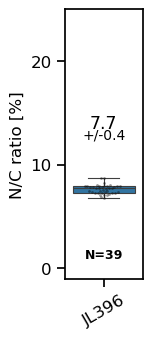

In [ ]:
##Defining Condition for adding data (number of cells, average value) on the plot
Strain=['JL396']

a4_dims = (1, 3.5)
fig, x = plt.subplots(figsize=a4_dims)
sns.set_context("notebook", font_scale=1.5)

ax=sns.boxplot(x="Strain",y="NC",data=data,showfliers=False,linewidth=0.8)
ax=sns.swarmplot(x="Strain",y="NC",data=data,size=2,color='k', alpha=0.4) # and slightly transparent

plt.ylim([-1,25])
plt.ylabel('N/C ratio [%]',fontsize=12)
plt.xlabel('')
##Adding the information automatically on the violin plot
pos = range(len(data['Strain'].value_counts().values)) ##Nb of "condition"
Nb=[] #create a list with the Number of cell in it
for i in range(len(Strain)):
    Nb.append(len(data[(data['Strain']==Strain[i])])-ToExcluded)
Nb=[str(x) for x in Nb]
Nb=["N=" + i for i in Nb]
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick], 1, Nb[tick], horizontalalignment='center', size='9',weight='semibold', color='k') #, weight='semibold'

Value=[]
for i in range(len(Strain)):
    Value.append(round(data[(data['Strain']==Strain[i])]['NC'].median(),1))
Value=[str(x) for x in Value]
Value=[i for i in Value]
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick], 13.5, Value[tick], horizontalalignment='center', size='x-small', color='k')

err=[]
for i in range(len(Strain)):
    err.append(round(data[(data['Strain']==Strain[i])]['NC'].std(),1))
err=[str(x) for x in err]
err=["+/-" +i for i in err]
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick], 12.5, err[tick], horizontalalignment='center', size=10, color='k')

plt.xticks(rotation=30)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
#plt.title('NC Ratio after hypertonic shocks', fontsize=15)

#plt.savefig(locout+"Figures/NC-"+str(Strain)+"-"+Rep+"_BoxPlot.pdf",bbox_inches='tight')
